### Bagging and Boosting on Pima Indian Diabetes Dataset:

#### 1) Importing Necessary Libraries:

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

#### 2) Loading Data:

In [2]:
df = pd.read_csv('pima-indians-diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- All features seem Numeric and Continuous.
- Target (Outcome) is Categorical.

#### 3) Data Transformations:

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

##### 1) Pregnancies:

In [8]:
df['Pregnancies']

0       6
1       1
2       8
3       1
4       0
       ..
763    10
764     2
765     5
766     1
767     1
Name: Pregnancies, Length: 768, dtype: int64

In [9]:
df['Pregnancies'].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

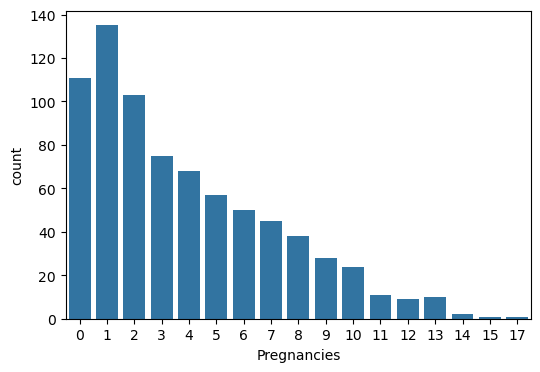

In [10]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'Pregnancies')
plt.show()

- Pregnancies is a Discrete Numeric Feature with a Right Tailed Distribution.
- As all our models in this notebook are going to be tree based, we can leave the feature as is, as tree models take care of this kind of features efficiently.
- For distance based models like Logistic Regression, we can use bining on this features to transform it and then use one hot encoding on it.

In [12]:
pregnancies_pipe = Pipeline([
    ('scaler', StandardScaler())
])

##### 2) Glucose:

In [13]:
df['Glucose']

0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64

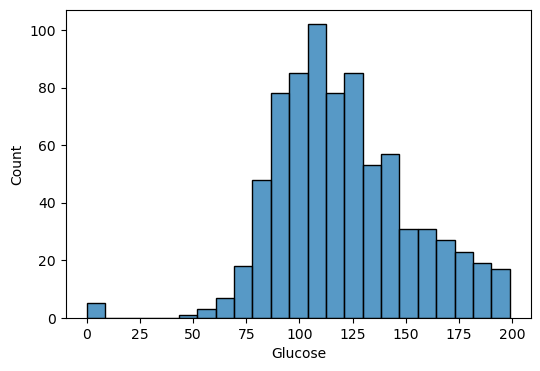

In [14]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Glucose')
plt.show()

In [15]:
glucose_pipe = Pipeline([
    ('scaler', StandardScaler())
])

##### 3) BloodPressure:

In [17]:
df['BloodPressure']

0      72
1      66
2      64
3      66
4      40
       ..
763    76
764    70
765    72
766    60
767    70
Name: BloodPressure, Length: 768, dtype: int64

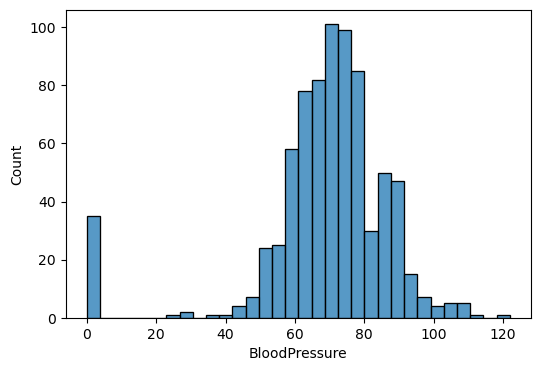

In [18]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'BloodPressure')
plt.show()

In [19]:
bp_pipe = Pipeline([
    ('scaler', StandardScaler())
])

##### 4) SkinThickness:

In [21]:
df['SkinThickness']

0      35
1      29
2       0
3      23
4      35
       ..
763    48
764    27
765    23
766     0
767    31
Name: SkinThickness, Length: 768, dtype: int64

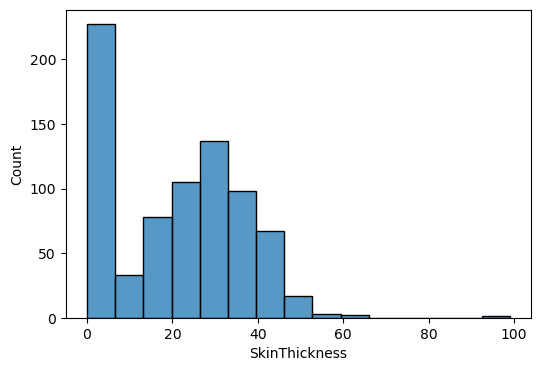

In [22]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'SkinThickness')
plt.show()

In [29]:
skin_pipe = Pipeline([
    ('scaler', StandardScaler())
])

##### 5) Insulin:

In [31]:
df['Insulin']

0        0
1        0
2        0
3       94
4      168
      ... 
763    180
764      0
765    112
766      0
767      0
Name: Insulin, Length: 768, dtype: int64

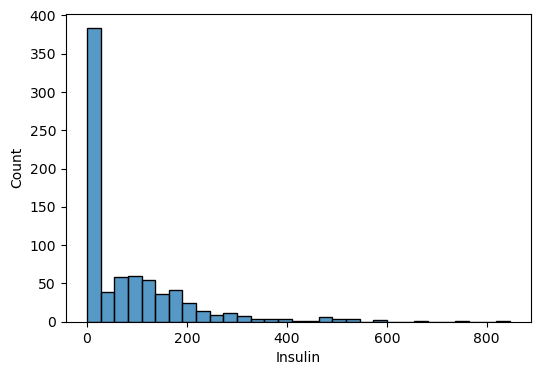

In [32]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Insulin')
plt.show()

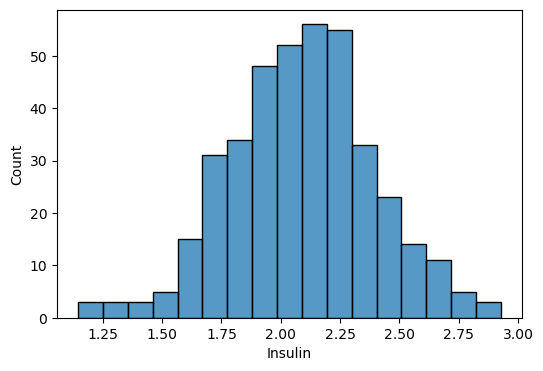

In [34]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Insulin'].apply(np.log10))
plt.show()

In [36]:
insulin_pipe = Pipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

##### 6) BMI:

In [38]:
df['BMI']

0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64

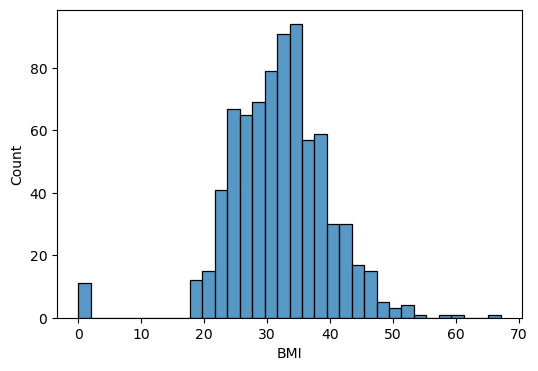

In [39]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'BMI')
plt.show()

In [41]:
bmi_pipe = Pipeline([
    ('scaler', StandardScaler())
])

##### 7) DiabetesPedigreeFunction:

In [43]:
df['DiabetesPedigreeFunction']

0      0.627
1      0.351
2      0.672
3      0.167
4      2.288
       ...  
763    0.171
764    0.340
765    0.245
766    0.349
767    0.315
Name: DiabetesPedigreeFunction, Length: 768, dtype: float64

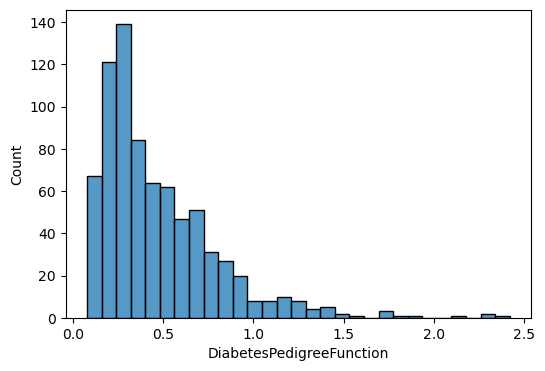

In [44]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'DiabetesPedigreeFunction')
plt.show()

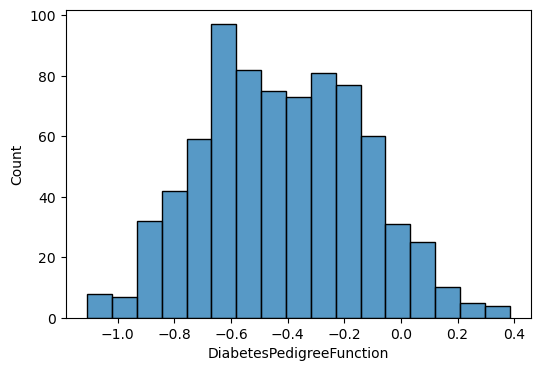

In [49]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['DiabetesPedigreeFunction'].apply(np.log10))
plt.show()

In [50]:
dpf_pipe = Pipeline([
    ('transformer', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

##### 8) Age:

In [52]:
df['Age']

0      50
1      31
2      32
3      21
4      33
       ..
763    63
764    27
765    30
766    47
767    23
Name: Age, Length: 768, dtype: int64

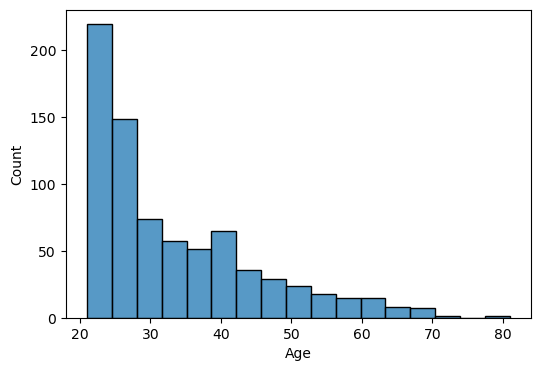

In [53]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Age')
plt.show()

In [62]:
age_pipe = Pipeline([
    ('scaler', StandardScaler()) # None of the transformations work to make distribution normal.
])

#### 4) Final Column Transformer:

In [64]:
preprocessor = ColumnTransformer([
    ('Pregnancies', pregnancies_pipe, ['Pregnancies']),
    ('Glucose', glucose_pipe, ['Glucose']),
    ('BloodPressure', bp_pipe, ['BloodPressure']),
    ('SkinThickness', skin_pipe, ['SkinThickness']),
    ('Insulin', insulin_pipe, ['Insulin']),
    ('BMI', bmi_pipe, ['BMI']),
    ('DiabetesPedigreeFunction', dpf_pipe, ['DiabetesPedigreeFunction']),
    ('Age', age_pipe, ['Age'])
])